# Heart Disease Prediction Using Decision Tree Algorithm
## Machine Learning Project

In [12]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [15]:
import pandas as pd

# Add column names
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load dataset
df = pd.read_csv(
    r"C:\Users\USER\Downloads\heart\processed.cleveland.data",
    names=column_names
)

# Show first rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Dataset overview

In [19]:
# Number of rows and columns
print('Dataset Shape:', df.shape)

# Dataset information
print('\nDataset Information:\n')
print(df.info())

# Statistical summary
print('\nSummary Statistics:\n')
print(df.describe())

Dataset Shape: (303, 14)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB
None

Summary Statistics:

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.0000

Observations
-The dataset contains patient clinical information.
-The target variable indicates the presence or absence of heart disease.
-Features include age, cholesterol level, chest pain type, blood pressure, etc.

In [20]:
# Missing values
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Observation:
no missing values

# EDA

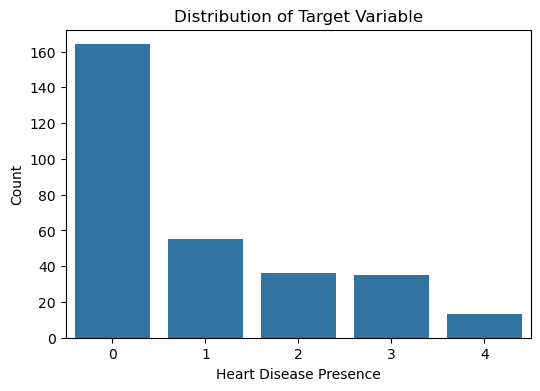

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable')
plt.xlabel('Heart Disease Presence')
plt.ylabel('Count')
plt.show()

#Insight
The dataset appears relatively balanced.
Both classes are adequately represented.

# Age distribution

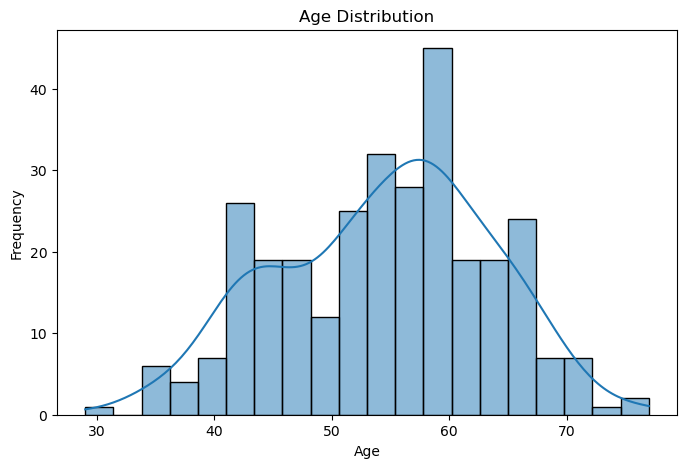

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#Insight
Most patients fall within the middle-age group.
Heart disease risk generally increases with age.

# Cholesterol Distribution

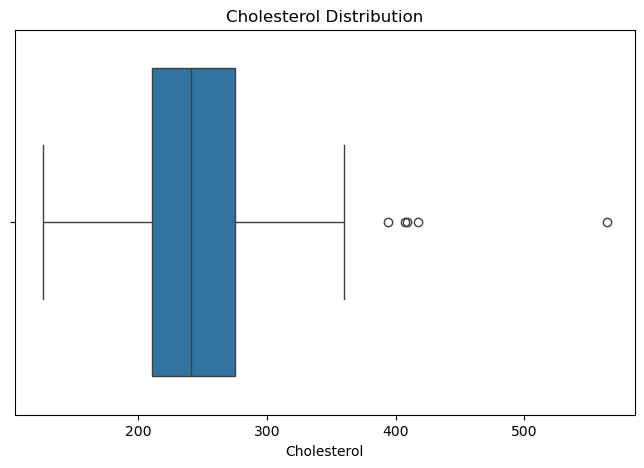

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['chol'])
plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.show()

#Insight
Some outliers are present in cholesterol values.
High cholesterol may contribute to heart disease risk.

# Chest Pain Type vs Target

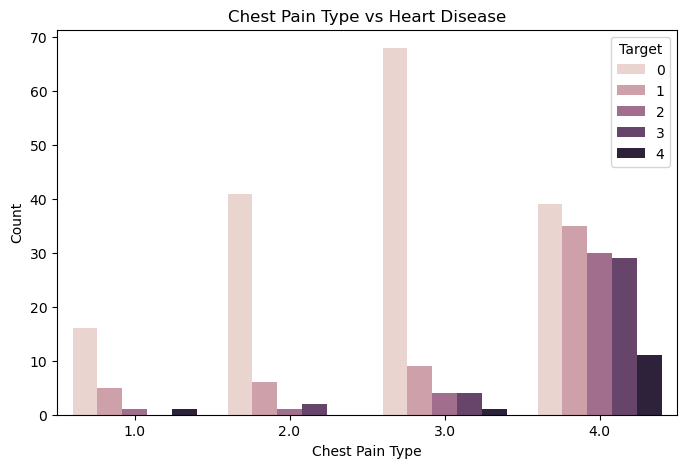

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(x='cp', hue='target', data=df)

plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')

plt.legend(title='Target')

plt.show()

#Insight
Certain chest pain categories are more associated with heart disease.

# Correlation Heatmap

In [28]:
# Replace ? with NaN

df = df.replace('?', np.nan)

In [29]:
# Convert all columns to numeric

df = df.apply(pd.to_numeric)

In [30]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [31]:
df['ca'].fillna(df['ca'].median(), inplace=True)

df['thal'].fillna(df['thal'].median(), inplace=True)

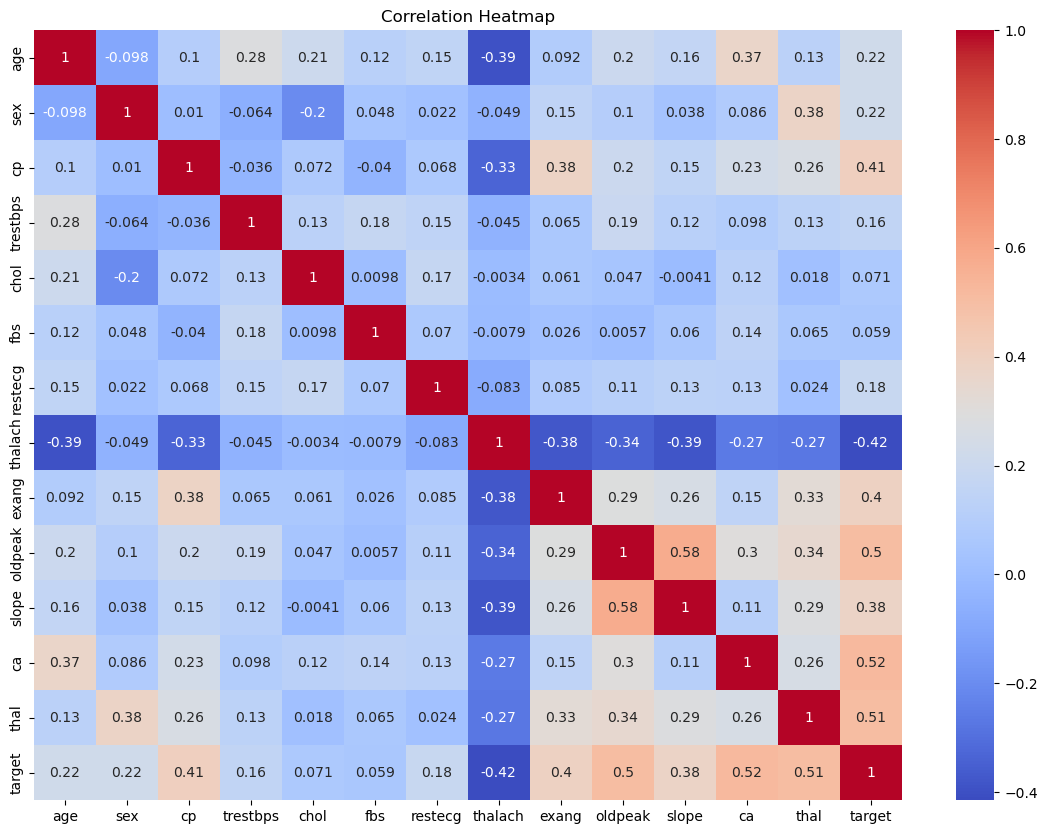

In [32]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [33]:
# Convert target column into binary classification

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [34]:
# Separate features and target

X = df.drop('target', axis=1)

y = df['target']

# train test split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Build Decision Tree Model

In [37]:
from sklearn.tree import DecisionTreeClassifier

# Create model

dt_model = DecisionTreeClassifier(random_state=42)

# Train model

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Predictions

In [38]:
# Predict test data

y_pred = dt_model.predict(X_test)

# Accuracy Score



In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7213114754098361


# Classification Report

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[21 12]
 [ 5 23]]


# Confusion Matrix

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[21 12]
 [ 5 23]]


# visualization

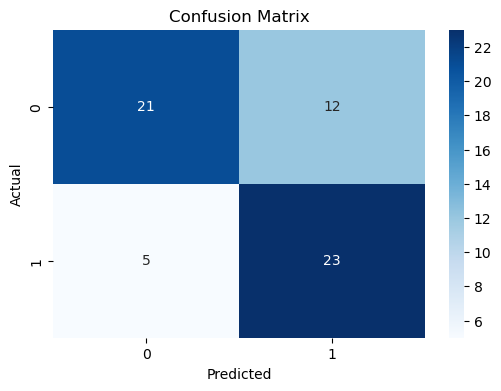

In [43]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# ROC-AUC Score

In [44]:
from sklearn.metrics import roc_auc_score

y_prob = dt_model.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.7288961038961038


# ROC Curve

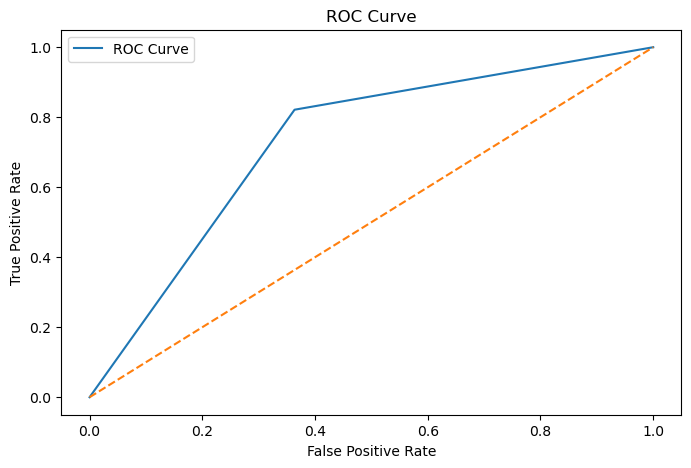

In [45]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label='ROC Curve')

plt.plot([0,1], [0,1], linestyle='--')

plt.title('ROC Curve')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

# Hyperparameter Tuning

In [46]:
from sklearn.model_selection import GridSearchCV

params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 10}


# Best Model

In [47]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, best_pred))

Optimized Accuracy: 0.7540983606557377


# Decision Tree Visualization

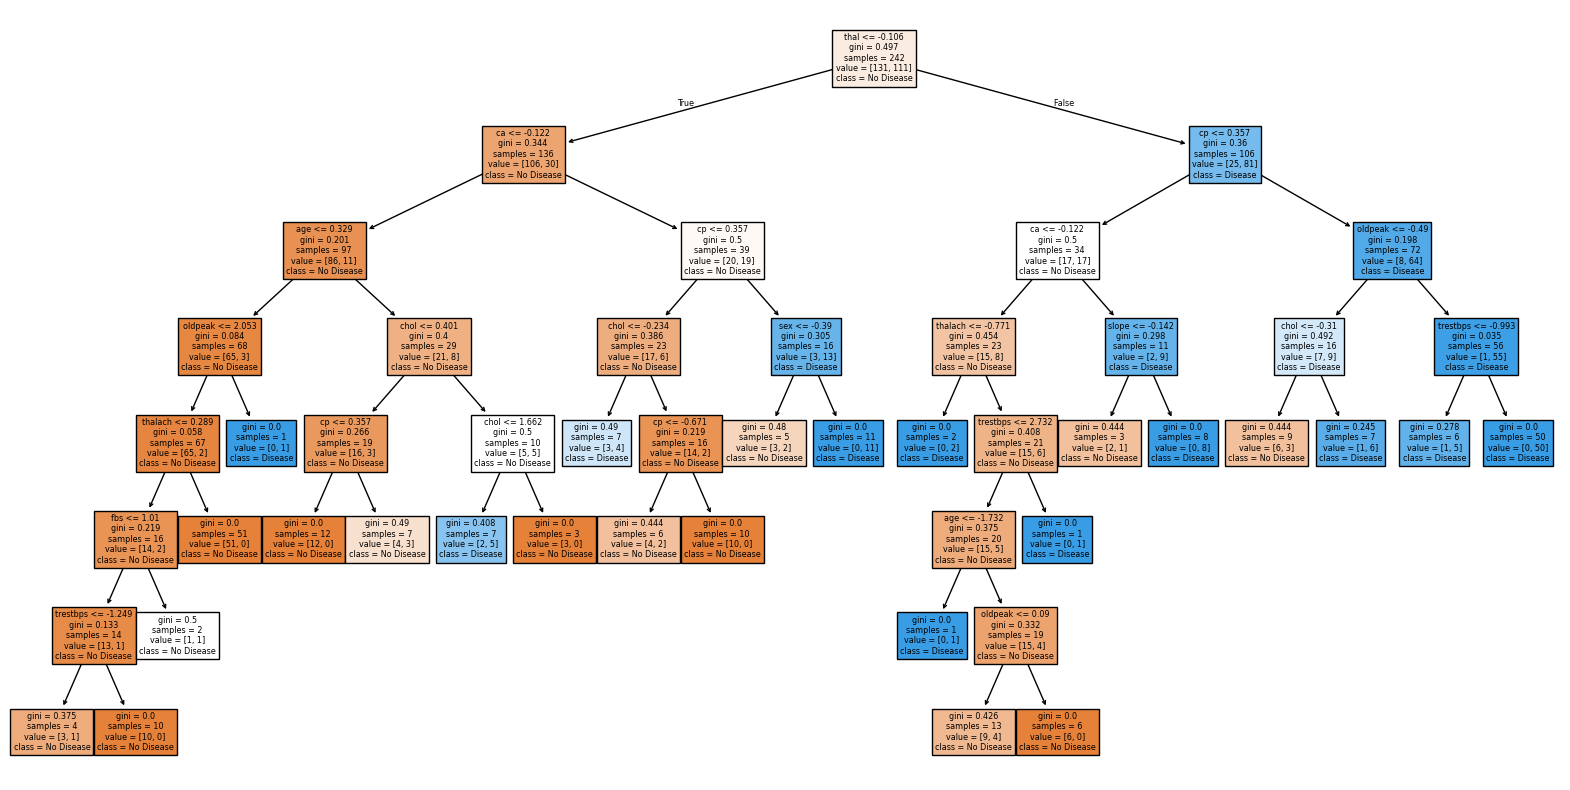

In [48]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    filled=True
)

plt.show()

# Feature Importance

In [49]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
12      thal    0.397127
2         cp    0.171315
11        ca    0.124829
4       chol    0.087750
9    oldpeak    0.079140
0        age    0.037995
1        sex    0.027922
7    thalach    0.025315
10     slope    0.021879
3   trestbps    0.019474
5        fbs    0.007252
6    restecg    0.000000
8      exang    0.000000


# Feature Importance Graph

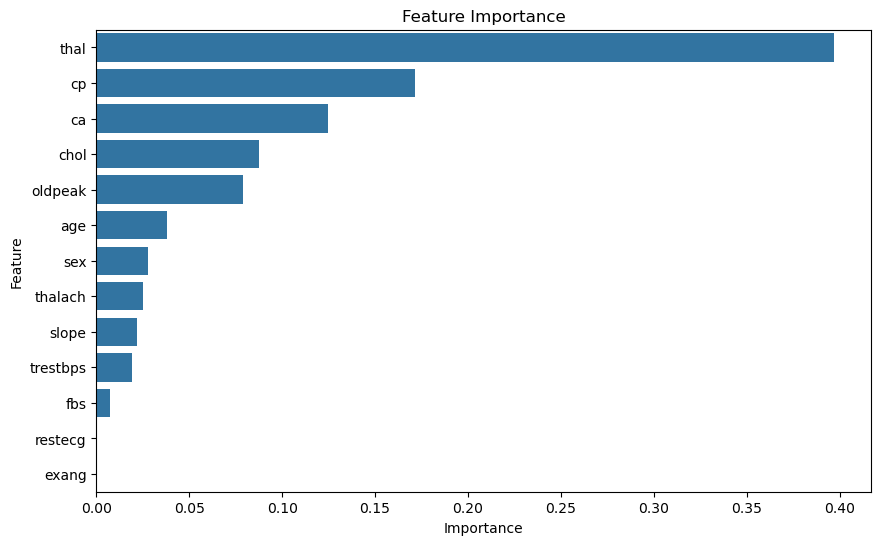

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

# Extract Decision Rules

In [51]:
from sklearn.tree import export_text

rules = export_text(
    best_model,
    feature_names=list(X.columns)
)

print(rules)

|--- thal <= -0.11
|   |--- ca <= -0.12
|   |   |--- age <= 0.33
|   |   |   |--- oldpeak <= 2.05
|   |   |   |   |--- thalach <= 0.29
|   |   |   |   |   |--- fbs <= 1.01
|   |   |   |   |   |   |--- trestbps <= -1.25
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- trestbps >  -1.25
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- fbs >  1.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- thalach >  0.29
|   |   |   |   |   |--- class: 0
|   |   |   |--- oldpeak >  2.05
|   |   |   |   |--- class: 1
|   |   |--- age >  0.33
|   |   |   |--- chol <= 0.40
|   |   |   |   |--- cp <= 0.36
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- cp >  0.36
|   |   |   |   |   |--- class: 0
|   |   |   |--- chol >  0.40
|   |   |   |   |--- chol <= 1.66
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- chol >  1.66
|   |   |   |   |   |--- class: 0
|   |--- ca >  -0.12
|   |   |--- cp <= 0.36
|   |   |   |--- chol <= -0.23
|   |   |   

# Logistic Regression Comparison

In [52]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, lr_pred)
)

Logistic Regression Accuracy: 0.8688524590163934


# Compare Models

In [53]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, best_pred),
        accuracy_score(y_test, lr_pred)
    ]
})

print(comparison)

                 Model  Accuracy
0        Decision Tree  0.754098
1  Logistic Regression  0.868852


# Comparison Graph

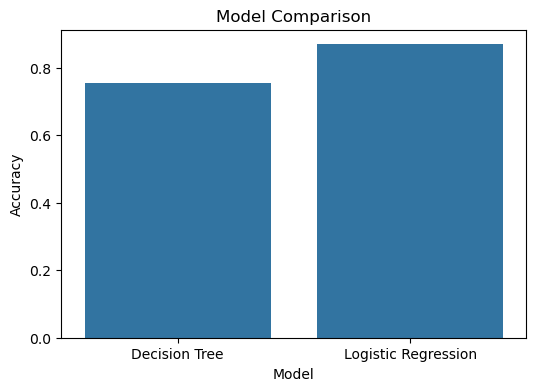

In [54]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title('Model Comparison')

plt.show()

# Conclusion

The Decision Tree model successfully predicted heart disease using clinical features.

Important features identified include:
- Chest pain type
- Maximum heart rate
- Oldpeak
- Age

Decision Trees provide good interpretability for healthcare applications.